# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## Подготовка данных

In [3]:
import re

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import phik
import seaborn as sns

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from phik.report import plot_correlation_matrix
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("data/autos.csv", parse_dates=True)
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [5]:
df = df.rename(columns=lambda x: re.sub(r'(?<!^)([A-Z])', r'_\1', x).lower())
df.columns

Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'kilometer', 'registration_month', 'fuel_type',
       'brand', 'repaired', 'date_created', 'number_of_pictures',
       'postal_code', 'last_seen'],
      dtype='object')

In [1]:
df['date_crawled'] = pd.to_datetime(df['date_crawled'])
df['date_created'] = pd.to_datetime(df['date_created'])
df['last_seen'] = pd.to_datetime(df['last_seen'])
df.info()

NameError: name 'pd' is not defined

In [7]:
# Проверим пропуски
df.isna().sum()

date_crawled              0
price                     0
vehicle_type          37490
registration_year         0
gearbox               19833
power                     0
model                 19705
kilometer                 0
registration_month        0
fuel_type             32895
brand                     0
repaired              71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

Столбцы, имеют пропуски:
* VehicleType - тип автомобильного кузова
* Gearbox — тип коробки передач
* Model - модель автомобиля
* FuelType — тип топлива
* Repaired — была машина в ремонте или нет

<AxesSubplot:>

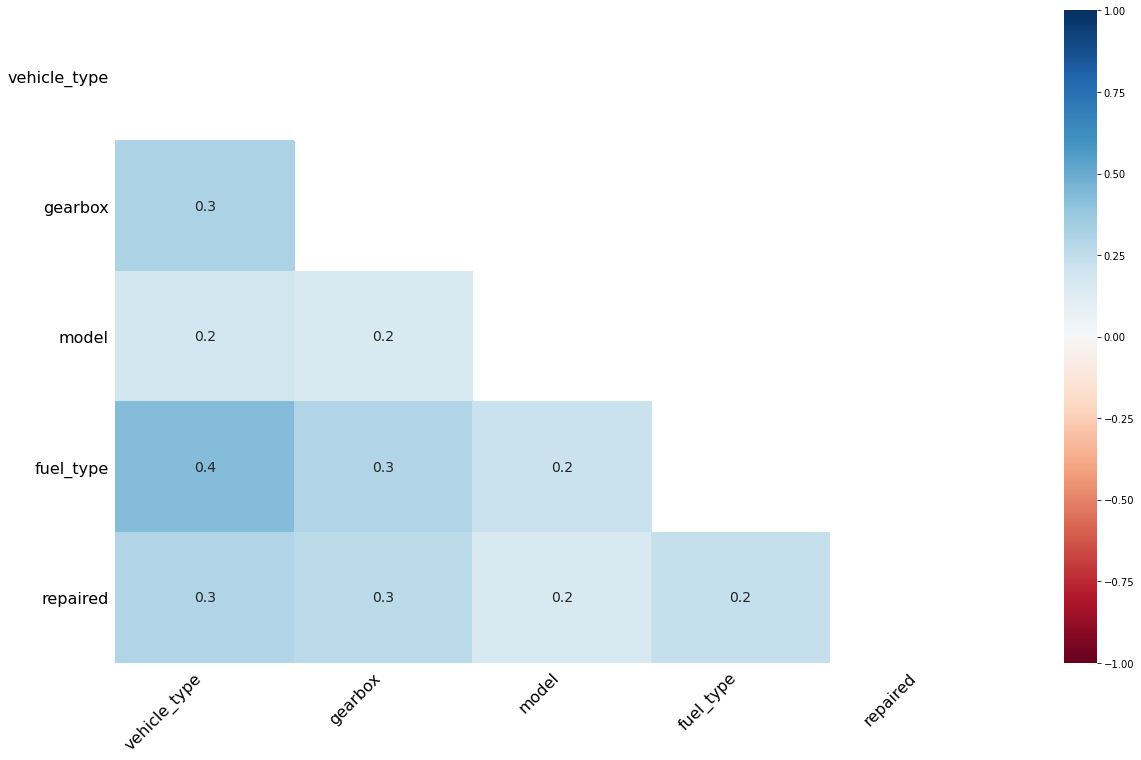

In [8]:
msno.heatmap(df)

In [9]:
print(f"Столбец 'vehicle_type' имеет уникальные значения: {df['vehicle_type'].unique()}")
print(f"Столбец 'gearbox' имеет уникальные значения: {df['gearbox'].unique()}")
print(f"Столбец 'model' имеет уникальные значения: {df['model'].unique()}")
print(f"Столбец 'fuel_type' имеет уникальные значения: {df['fuel_type'].unique()}")
print(f"Столбец 'repaired' имеет уникальные значения: {df['repaired'].unique()}")

Столбец 'vehicle_type' имеет уникальные значения: [nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']
Столбец 'gearbox' имеет уникальные значения: ['manual' 'auto' nan]
Столбец 'model' имеет уникальные значения: ['golf' nan 'grand' 'fabia' '3er' '2_reihe' 'other' 'c_max' '3_reihe'
 'passat' 'navara' 'ka' 'polo' 'twingo' 'a_klasse' 'scirocco' '5er'
 'meriva' 'arosa' 'c4' 'civic' 'transporter' 'punto' 'e_klasse' 'clio'
 'kadett' 'kangoo' 'corsa' 'one' 'fortwo' '1er' 'b_klasse' 'signum'
 'astra' 'a8' 'jetta' 'fiesta' 'c_klasse' 'micra' 'vito' 'sprinter' '156'
 'escort' 'forester' 'xc_reihe' 'scenic' 'a4' 'a1' 'insignia' 'combo'
 'focus' 'tt' 'a6' 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe'
 'sportage' 'sorento' 'v40' 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3'
 'almera' 'megane' 'lupo' 'r19' 'zafira' 'caddy' 'mondeo' 'cordoba' 'colt'
 'impreza' 'vectra' 'berlingo' 'tiguan' 'i_reihe' 'espace' 'sharan'
 '6_reihe' 'panda' 'up' 'seicento' 'ceed' '5_reihe' 'yeti'

Как будем поступать со строками в которых есть пропущенные значения в данных столбцах:
* Столбец "vehicle_type" заполним значением "unknown"
* Так как мы не можем определить модель автомобиля, то удалим строки, где пропущены значения в столбце "model"
* Так как мы не можем определить тип коробки передач автомобиля, то удалим строки, где пропущены значения в столбце "gearbox"
* Заполним пропуски в столбце "fuel_type" на "unknown"
* Предположим что в столбце "repaired" пропущенные данные являются скрытием информации о ремонте, так как это может снизить цену на авто, следовательно заполним пропуски значением "yes"
* Заменим "gasoline" на "petrol" в столбце "fuel_type", скрытый дубликат, эти два слова обозначают одно и то же

In [10]:
df.dropna(subset=['model'], inplace=True)
df.dropna(subset=['gearbox'], inplace=True)
df["fuel_type"] = df["fuel_type"].fillna("unknown")
df["vehicle_type"] = df["vehicle_type"].fillna("unknown")
df["repaired"] = df["repaired"].fillna("yes")
df.isna().sum()

date_crawled          0
price                 0
vehicle_type          0
registration_year     0
gearbox               0
power                 0
model                 0
kilometer             0
registration_month    0
fuel_type             0
brand                 0
repaired              0
date_created          0
number_of_pictures    0
postal_code           0
last_seen             0
dtype: int64

In [11]:
df['fuel_type'] = df['fuel_type'].replace("gasoline", "petrol")
print(f"Столбец 'fuel_type' имеет уникальные значения: {df['fuel_type'].unique()}")

Столбец 'fuel_type' имеет уникальные значения: ['petrol' 'unknown' 'lpg' 'other' 'hybrid' 'cng' 'electric']


In [12]:
df.duplicated().sum()

4

In [13]:
df = df.drop_duplicates()

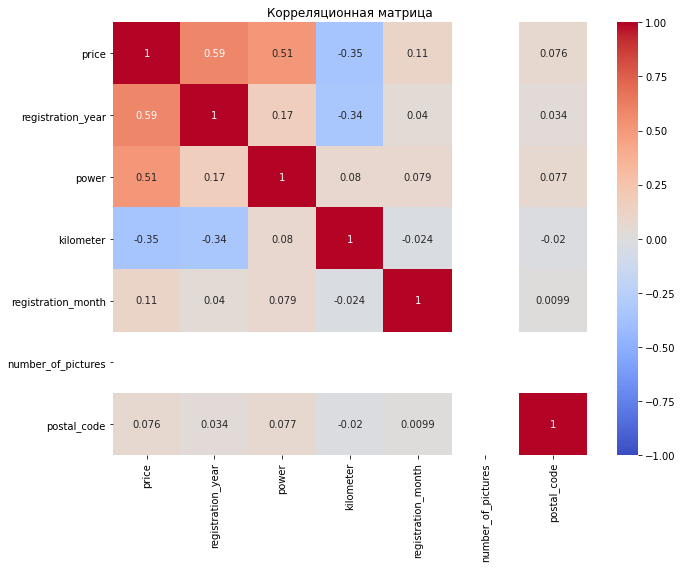

In [14]:
correlation_matrix = df.corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

In [15]:
print(f"В столбце 'date_crawled':\nмаксимальное значение - {df['date_crawled'].max()},\nминимальное - {df['date_crawled'].min()}")

В столбце 'date_crawled':
максимальное значение - 2016-04-07 14:36:58,
минимальное - 2016-03-05 14:06:22


 Столбцы:
 * "date_crawled" - не информативен, дата скачивания не имеет значения для цены
 * "registration_month" - слабая корреляция с целевым признаком
 * "date_created" - не информативен, дата создания анкеты не имеет значения для цены
 * "number_of_pictures" - не информативен, одни нулевые значения
 * "postal_code" - слабая корреляция с целевым признаком
 * "last_seen" - не информативен, дата последней активности не имеет значения для цены

Удалим их

In [16]:
df.drop(
    columns=[
        "date_crawled",
        "registration_month",
        "date_created",
        "number_of_pictures",
        "postal_code",
        "last_seen"
    ], inplace=True)
df.head()

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,fuel_type,brand,repaired
0,480,unknown,1993,manual,0,golf,150000,petrol,volkswagen,yes
2,9800,suv,2004,auto,163,grand,125000,petrol,jeep,yes
3,1500,small,2001,manual,75,golf,150000,petrol,volkswagen,no
4,3600,small,2008,manual,69,fabia,90000,petrol,skoda,no
5,650,sedan,1995,manual,102,3er,150000,petrol,bmw,yes


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 318958 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              318958 non-null  int64 
 1   vehicle_type       318958 non-null  object
 2   registration_year  318958 non-null  int64 
 3   gearbox            318958 non-null  object
 4   power              318958 non-null  int64 
 5   model              318958 non-null  object
 6   kilometer          318958 non-null  int64 
 7   fuel_type          318958 non-null  object
 8   brand              318958 non-null  object
 9   repaired           318958 non-null  object
dtypes: int64(4), object(6)
memory usage: 26.8+ MB


In [18]:
df.describe()

,price,registration_year,power,kilometer
count,318958.000000,318958.000000,318958.000000,318958.000000
mean,4608.905502,2003.427031,114.965265,128844.738179
std,4564.241216,30.517461,185.627579,36620.680186
min,0.000000,1000.000000,0.000000,5000.000000
25%,1200.000000,1999.000000,75.000000,125000.000000
50%,2900.000000,2003.000000,105.000000,150000.000000
75%,6700.000000,2008.000000,143.000000,150000.000000
max,20000.000000,9000.000000,20000.000000,150000.000000


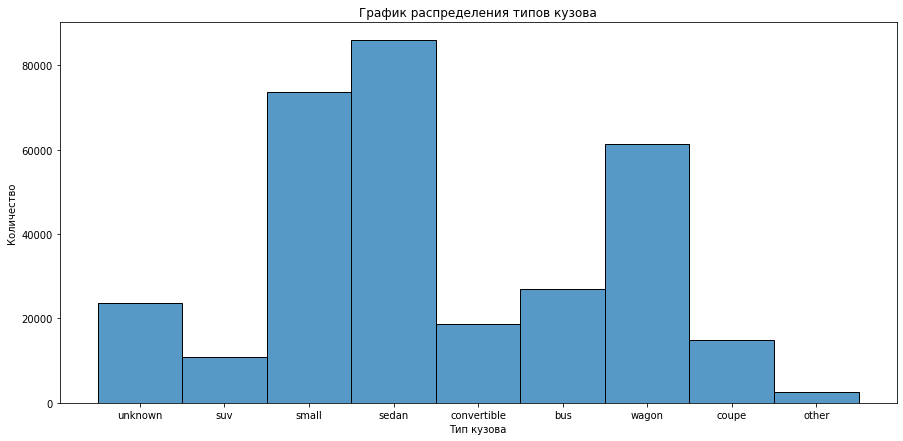

In [19]:
plt.figure(figsize=(15, 7))
sns.histplot(df, x="vehicle_type", bins=100)
plt.title('График распределения типов кузова')
plt.xlabel('Тип кузова')
plt.ylabel('Количество')
plt.show()

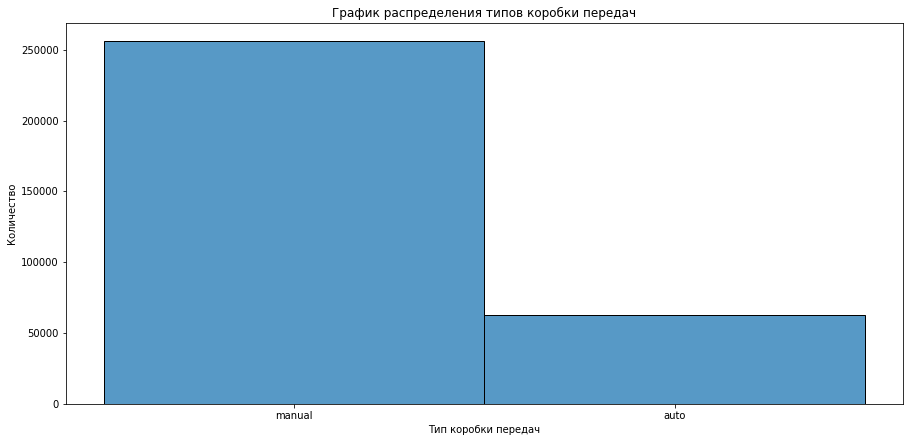

In [20]:
plt.figure(figsize=(15, 7))
sns.histplot(df, x="gearbox", bins=100)
plt.title('График распределения типов коробки передач')
plt.xlabel('Тип коробки передач')
plt.ylabel('Количество')
plt.show()

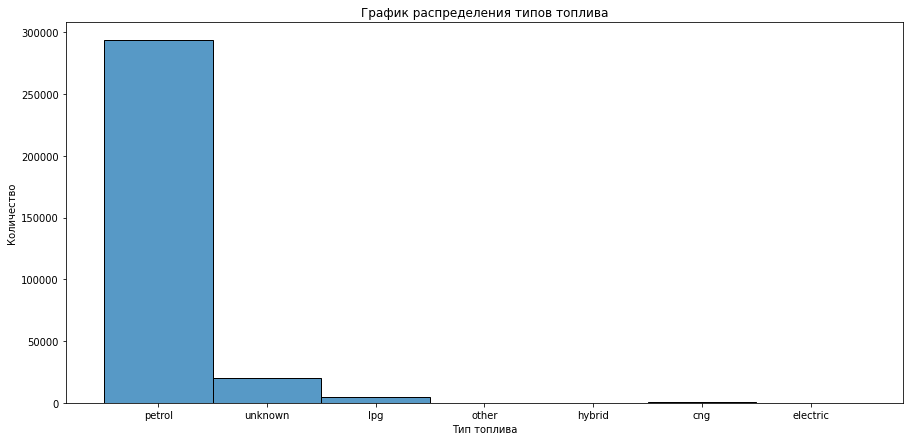

In [21]:
plt.figure(figsize=(15, 7))
sns.histplot(df, x="fuel_type", bins=50)
plt.title('График распределения типов топлива')
plt.xlabel('Тип топлива')
plt.ylabel('Количество')
plt.show()

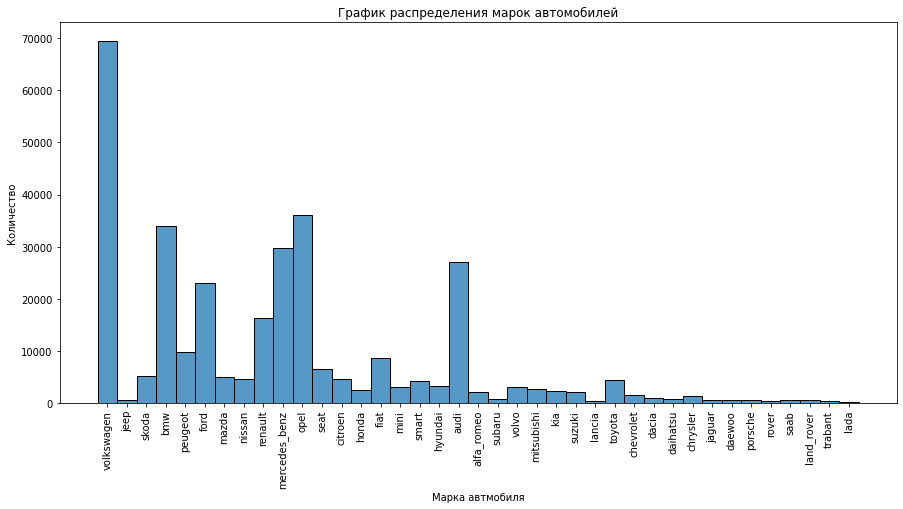

In [22]:
plt.figure(figsize=(15, 7))
sns.histplot(df, x="brand", bins=50)
plt.title('График распределения марок автомобилей')
plt.xlabel('Марка автмобиля')
plt.ylabel('Количество')
plt.xticks(rotation=90)
plt.show()

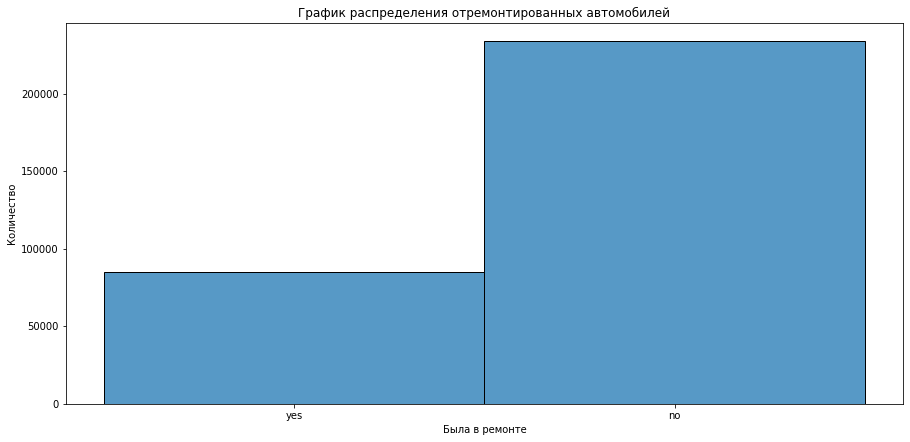

In [23]:
plt.figure(figsize=(15, 7))
sns.histplot(df, x="repaired", bins=50)
plt.title('График распределения отремонтированных автомобилей')
plt.xlabel('Была в ремонте')
plt.ylabel('Количество')
plt.show()

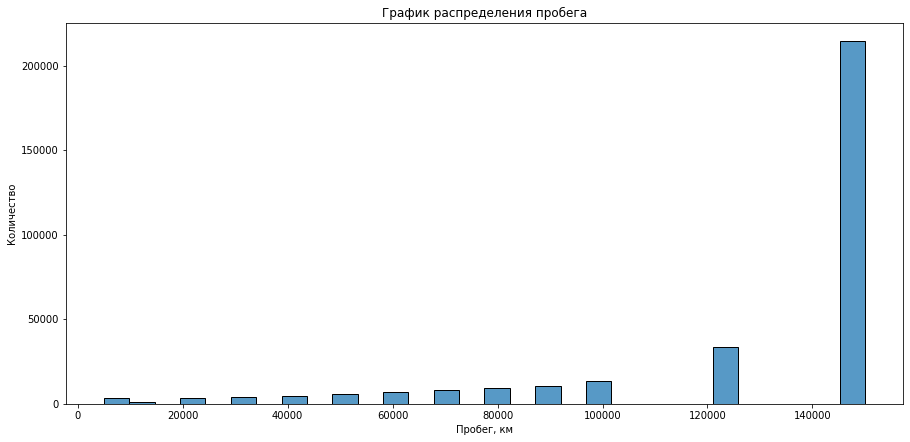

In [24]:
plt.figure(figsize=(15, 7))
sns.histplot(df, x="kilometer", bins=30)
plt.title('График распределения пробега')
plt.xlabel('Пробег, км')
plt.ylabel('Количество')
plt.show()

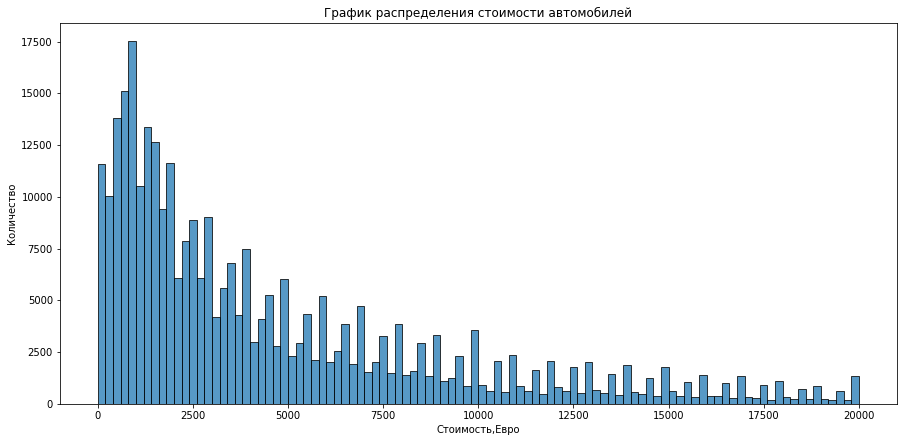

In [25]:
plt.figure(figsize=(15, 7))
sns.histplot(df, x="price", bins=100)
plt.title('График распределения стоимости автомобилей')
plt.xlabel('Стоимость,Евро')
plt.ylabel('Количество')
plt.show()

Как видно из графика в таблице присутствуют цены равные 0, такая цена может быть обусловлена выставлением авто на обмен("ключ в ключ"). Удалим эти строки

In [26]:
df = df[df['price'] != 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 311802 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              311802 non-null  int64 
 1   vehicle_type       311802 non-null  object
 2   registration_year  311802 non-null  int64 
 3   gearbox            311802 non-null  object
 4   power              311802 non-null  int64 
 5   model              311802 non-null  object
 6   kilometer          311802 non-null  int64 
 7   fuel_type          311802 non-null  object
 8   brand              311802 non-null  object
 9   repaired           311802 non-null  object
dtypes: int64(4), object(6)
memory usage: 26.2+ MB


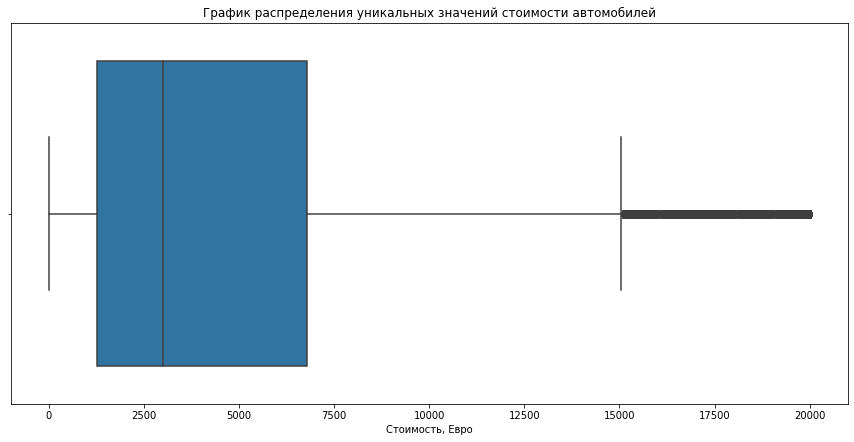

In [27]:
plt.figure(figsize=(15, 7))
sns.boxplot(x=df["price"])
plt.title('График распределения уникальных значений стоимости автомобилей')
plt.xlabel('Стоимость, Евро')
plt.show()

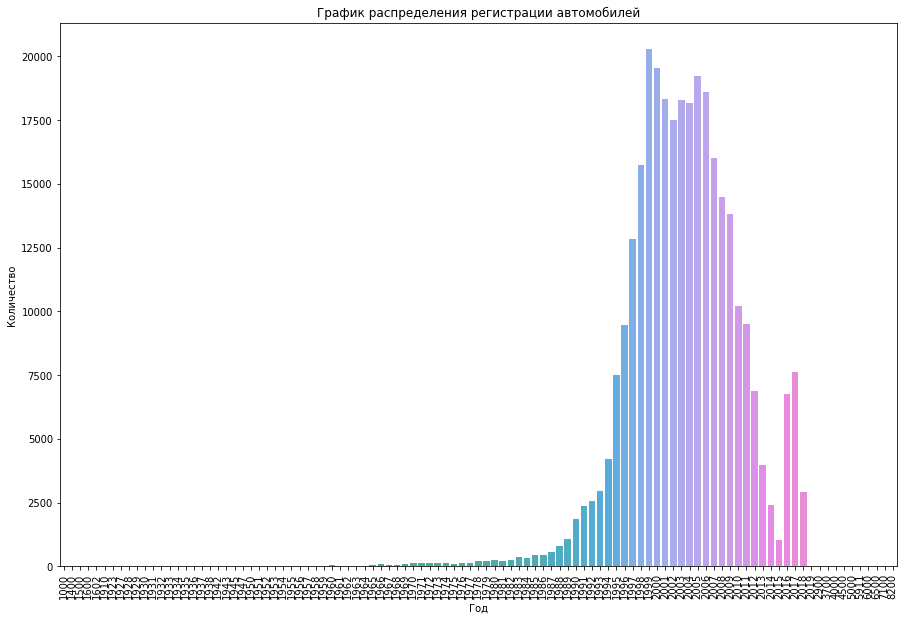

In [28]:
plt.figure(figsize=(15, 10))
sns.countplot(data=df, x="registration_year")
plt.title('График распределения регистрации автомобилей')
plt.xlabel('Год')
plt.ylabel('Количество')
plt.xticks(rotation=90)
plt.show()

Как видно из графика, есть даты регистрации автомобилей после даты скачивания данных, удалим их

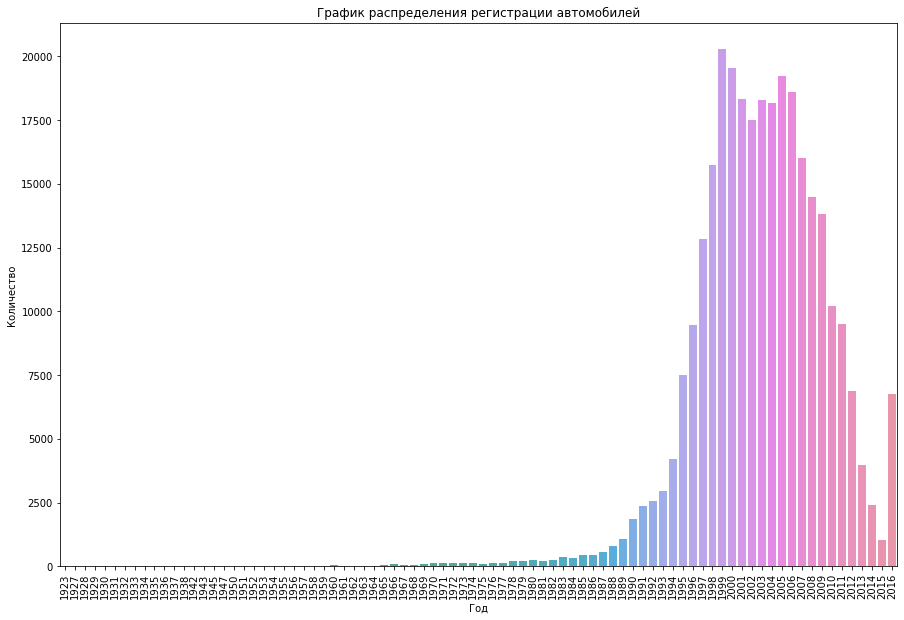

In [29]:
df = df[(df['registration_year'] >= 1920) & (df['registration_year'] < 2017)]
plt.figure(figsize=(15, 10))
sns.countplot(data=df, x="registration_year")
plt.title('График распределения регистрации автомобилей')
plt.xlabel('Год')
plt.ylabel('Количество')
plt.xticks(rotation=90)
plt.show()

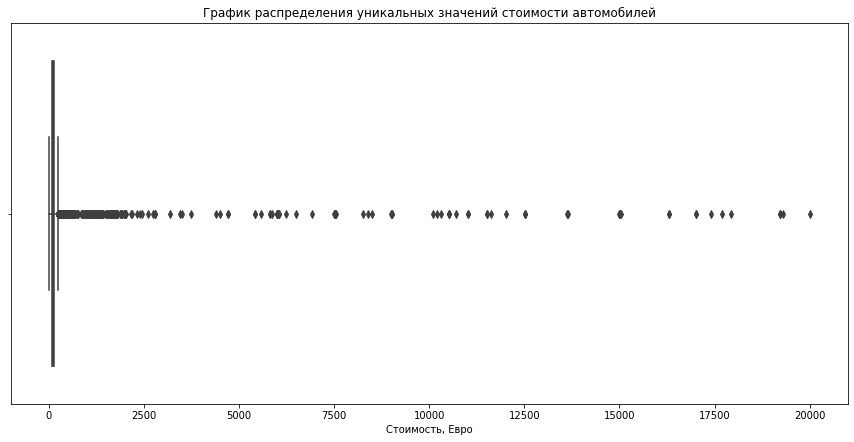

In [30]:
plt.figure(figsize=(15, 7))
sns.boxplot(x=df["power"])
plt.title('График распределения уникальных значений стоимости автомобилей')
plt.xlabel('Стоимость, Евро')
plt.show()

На сегодняшний день самый мощный автомобиль имеет 2300 л.с. Удалим строки со значениями больше 2300. Так же строки со значениями 0, заменим медианым по столбцу "Model"

In [31]:
df = df[df['power'] < 2301]
df[df['power'] == 0]

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,fuel_type,brand,repaired
0,480,unknown,1993,manual,0,golf,150000,petrol,volkswagen,yes
54,4700,wagon,2005,manual,0,signum,150000,unknown,opel,no
55,550,wagon,1999,manual,0,astra,150000,petrol,opel,yes
70,800,small,1993,manual,0,polo,150000,petrol,volkswagen,no
90,2400,sedan,2003,manual,0,a4,150000,petrol,audi,yes
...,...,...,...,...,...,...,...,...,...,...
354332,7900,bus,2007,manual,0,b_klasse,125000,petrol,mercedes_benz,no
354335,390,small,1997,auto,0,corsa,100000,petrol,opel,yes
354336,3299,unknown,2005,auto,0,outlander,150000,petrol,mitsubishi,yes
354346,2600,unknown,2005,auto,0,c_klasse,150000,unknown,mercedes_benz,yes


In [32]:
df['power'] = df['power'].replace(0, np.nan)
df['power'] = df['power'].fillna(df.groupby('model')['power'].transform('median'))
df.isna().sum()

price                0
vehicle_type         0
registration_year    0
gearbox              0
power                1
model                0
kilometer            0
fuel_type            0
brand                0
repaired             0
dtype: int64

In [33]:
df = df.dropna()
df.isna().sum()

price                0
vehicle_type         0
registration_year    0
gearbox              0
power                0
model                0
kilometer            0
fuel_type            0
brand                0
repaired             0
dtype: int64

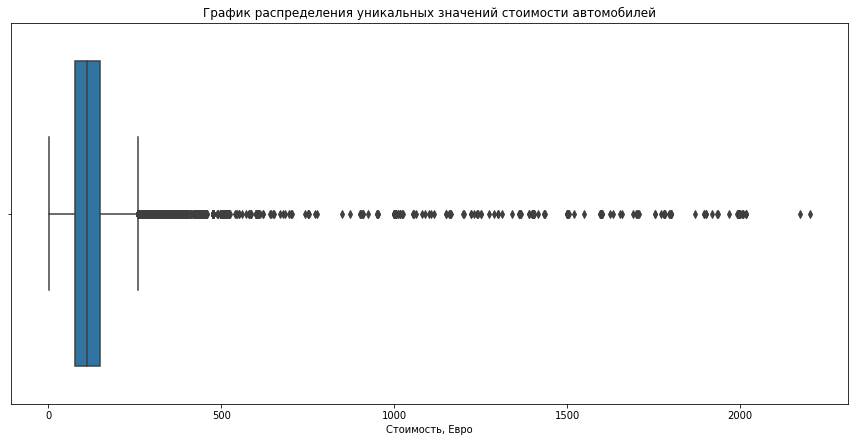

In [34]:
plt.figure(figsize=(15, 7))
sns.boxplot(x=df["power"])
plt.title('График распределения уникальных значений стоимости автомобилей')
plt.xlabel('Стоимость, Евро')
plt.show()

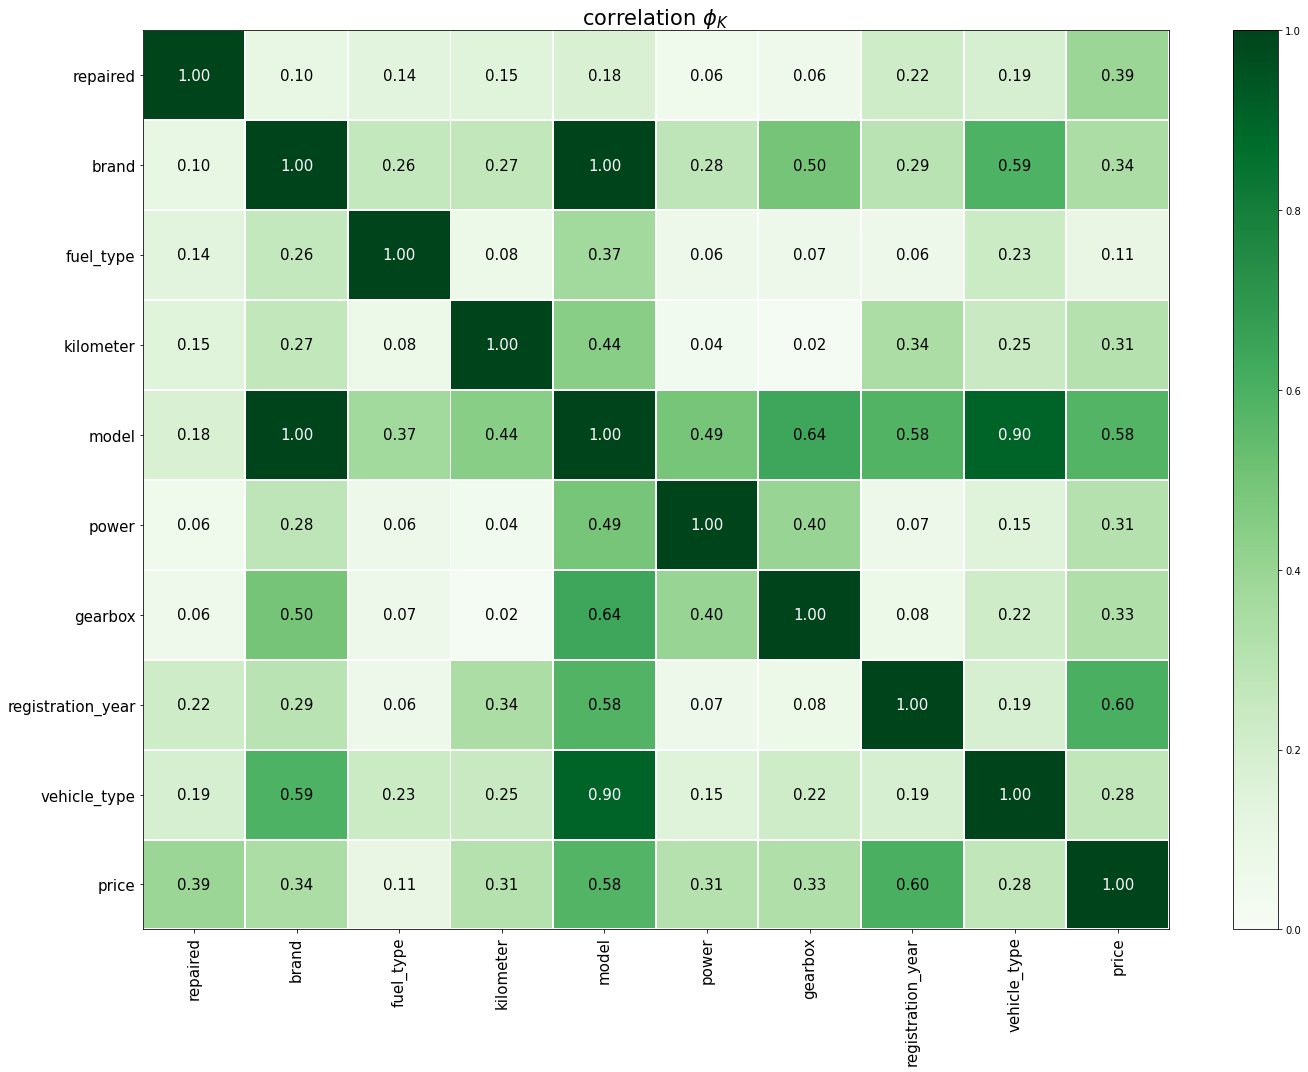

In [35]:
phik_overview = phik.phik_matrix(df, interval_cols=df.select_dtypes(include='number').columns)
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Судя по матрице корреляции, столбец "model" имеет высокую корреляцию со стоблцами "brand" и "vehicle_type" стоит удалить этот столбец

In [36]:
df = df.drop(columns=['model'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 301144 entries, 0 to 354368
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   price              301144 non-null  int64  
 1   vehicle_type       301144 non-null  object 
 2   registration_year  301144 non-null  int64  
 3   gearbox            301144 non-null  object 
 4   power              301144 non-null  float64
 5   kilometer          301144 non-null  int64  
 6   fuel_type          301144 non-null  object 
 7   brand              301144 non-null  object 
 8   repaired           301144 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 23.0+ MB


Общий вывод:

1. Проверили таблицу на пропуски, удалили и заменили их
2. Удалили дубликаты
3. Удалили аномльные значения, и некотрые заменили на медианое значение
4. Удалили неинформативные столбцы
5. У целевого признака наилучшая корреляция с "Model" и "RegistrationYear"

## Обучение моделей

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 301144 entries, 0 to 354368
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   price              301144 non-null  int64  
 1   vehicle_type       301144 non-null  object 
 2   registration_year  301144 non-null  int64  
 3   gearbox            301144 non-null  object 
 4   power              301144 non-null  float64
 5   kilometer          301144 non-null  int64  
 6   fuel_type          301144 non-null  object 
 7   brand              301144 non-null  object 
 8   repaired           301144 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 23.0+ MB


In [38]:
df = df.reset_index(inplace=False, drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301144 entries, 0 to 301143
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   price              301144 non-null  int64  
 1   vehicle_type       301144 non-null  object 
 2   registration_year  301144 non-null  int64  
 3   gearbox            301144 non-null  object 
 4   power              301144 non-null  float64
 5   kilometer          301144 non-null  int64  
 6   fuel_type          301144 non-null  object 
 7   brand              301144 non-null  object 
 8   repaired           301144 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 20.7+ MB


In [39]:
def rmse_scorer(y_true, y_pred):
    """Функция вычисления RMSE."""
    mse = mean_squared_error(y_true, y_pred)
    result = np.sqrt(mse)
    return result

rmse_score = make_scorer(rmse_scorer, greater_is_better=True)

In [40]:
features = df.drop('price', axis=1)
target = df['price']

In [41]:
cat_cols = features.select_dtypes(include=['object']).columns.to_list()
num_cols = features.select_dtypes(exclude=['object']).columns.to_list()
cat_cols, num_cols

(['vehicle_type', 'gearbox', 'fuel_type', 'brand', 'repaired'],
 ['registration_year', 'power', 'kilometer'])

In [42]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.4, random_state=42)

In [43]:
encoder = OneHotEncoder(drop='first', handle_unknown='error')
scaler = StandardScaler()

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_cols),
        ('cat', encoder, cat_cols)
    ], remainder='passthrough'
)

In [45]:
pipeline_lr = Pipeline(
    [
        ('preprocessor', preprocessor),
        ("models", LinearRegression())
    ]
)
pipeline_xgb = Pipeline(
    [
        ('preprocessor', preprocessor),
        ("models", XGBRegressor(random_state=42))
    ]
)
param_grid_lr = [
    {
        'models': [LinearRegression()],
    }
]
param_grid_xgb = [
    {
        'models': [XGBRegressor(random_state=42)],
        'models__learning_rate': [0.01, 0.1],
        'models__n_estimators': [500, 1000],
        'models__max_depth': [8, 9, 10],
        'models__objective': ['reg:squarederror']
    }
]

In [46]:
gs = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    scoring=rmse_score,
    cv=5,
    n_jobs=-1
)
gs.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['registration_year',
                                                                          'power',
                                                                          'kilometer']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['vehicle_type',
                                                                          'gearbox',
                                                                          'fuel_type',
                                                                          'brand',
                                                                          'repaired'])])),
                                       ('models', LinearRegression())]),
             n_jobs=-1, param_grid=[{'models': [LinearRegression()]}],
             scoring=make_scorer(rmse_scorer, response_method='predict'))

In [47]:
print("Лучший результат:", gs.best_score_)
print("Лучшие параметры:", gs.best_params_)

Лучший результат: 2898.812740371959
Лучшие параметры: {'models': LinearRegression()}


In [48]:
model_lr = gs.best_estimator_
model_lr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['registration_year', 'power',
                                                   'kilometer']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['vehicle_type', 'gearbox',
                                                   'fuel_type', 'brand',
                                                   'repaired'])])),
                ('models', LinearRegression())])

In [49]:
result_lr = gs.cv_results_
result_lr

{'mean_fit_time': array([5.9484457]),
 'std_fit_time': array([0.34527681]),
 'mean_score_time': array([0.22798538]),
 'std_score_time': array([0.03481221]),
 'param_models': masked_array(data=[LinearRegression()],
              mask=[False],
        fill_value='?',
             dtype=object),
 'params': [{'models': LinearRegression()}],
 'split0_test_score': array([2937.19986178]),
 'split1_test_score': array([2925.09330406]),
 'split2_test_score': array([2880.75998873]),
 'split3_test_score': array([2866.53305466]),
 'split4_test_score': array([2884.47749263]),
 'mean_test_score': array([2898.81274037]),
 'std_test_score': array([27.34087927]),
 'rank_test_score': array([1], dtype=int32)}

In [75]:
t_train_lr = round(result_lr['mean_fit_time'][0], 3)
t_prediction_lr = round(result_lr['mean_score_time'][0], 3)
rmse_lr = round(gs.best_score_, 3)
print(f"Время обучения LinearRegression {t_train_lr}")
print(f"Время предсказания LinearRegression {t_prediction_lr}")

Время обучения LinearRegression 5.948
Время предсказания LinearRegression 0.228


In [50]:
rs_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_grid_xgb,
    n_iter=2,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
rs_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['registration_year',
                                                                                'power',
                                                                                'kilometer']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['vehicle_type',
                                                                                'gearbox',
                                                                                'fuel_type',
                                                                                'brand',
                                                                                'repaired'])])),
                                             ('models',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=No...
                                                                 min_child_weight=None,
                                                                 missing=nan,
                                                                 monotone_constraints=None,
                                                                 multi_strategy=None,
                                                                 n_estimators=None,
                                                                 n_jobs=None,
                                                                 num_parallel_tree=None,
                                                                 random_state=42, ...)],
                                         'models__learning_rate': [0.01, 0.1],
                                         'models__max_depth': [8, 9, 10],
                                         'models__n_estimators': [500, 1000],
                                         'models__objective': ['reg:squarederror']}],
                   random_state=42, scoring='neg_root_mean_squared_error')

In [93]:
print("Лучший результат:", abs(rs_xgb.best_score_))
print("Лучшие параметры:", rs_xgb.best_params_)

Лучший результат: 1647.1168212890625
Лучшие параметры: {'models__objective': 'reg:squarederror', 'models__n_estimators': 500, 'models__max_depth': 10, 'models__learning_rate': 0.1, 'models': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)}


In [52]:
model_xgb = rs_xgb.best_estimator_
model_xgb

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['registration_year', 'power',
                                                   'kilometer']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['vehicle_type', 'gearbox',
                                                   'fuel_type', 'brand',
                                                   'repaired'])])),
                ('models',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsampl...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=10, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [53]:
results_xgb = rs_xgb.cv_results_
results_xgb

{'mean_fit_time': array([ 8.65980188, 14.17168522]),
 'std_fit_time': array([0.08409843, 0.08309699]),
 'mean_score_time': array([ 7.49964817, 18.65882031]),
 'std_score_time': array([0.18794977, 0.73147556]),
 'param_models__objective': masked_array(data=['reg:squarederror', 'reg:squarederror'],
              mask=[False, False],
        fill_value='?',
             dtype=object),
 'param_models__n_estimators': masked_array(data=[500, 1000],
              mask=[False, False],
        fill_value=999999),
 'param_models__max_depth': masked_array(data=[10, 9],
              mask=[False, False],
        fill_value=999999),
 'param_models__learning_rate': masked_array(data=[0.1, 0.1],
              mask=[False, False],
        fill_value=1e+20),
 'param_models': masked_array(data=[XGBRegressor(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=None, device=None, ear

In [97]:
t_train_xgb = round(results_xgb['mean_fit_time'][0], 3)
t_pred_xgb = round(results_xgb['mean_score_time'][0], 3)
rmse_xgb = abs(round(rs_xgb.best_score_, 3))
print(f"Время обучения XGBRegressor {t_train_xgb}")
print(f"Время предсказания XGBRegressor {t_pred_xgb}")

Время обучения XGBRegressor 8.66
Время предсказания XGBRegressor 7.5


In [54]:
cat_boost = CatBoostRegressor(cat_features=cat_cols, random_state=42)
lgbm = LGBMRegressor(random_state=42)

In [55]:
cat_param_grid = {
    'iterations': [1000, 500],
    'learning_rate': [0.01, 0.1],
    'depth': [10, 11, 12],
    'loss_function': ['RMSE'],
    'early_stopping_rounds': [50]
}

In [56]:
cat_rs = RandomizedSearchCV(
    cat_boost,
    cat_param_grid,
    n_iter=2,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
cat_rs.fit(X_train, y_train)

0:	learn: 4534.8185853	total: 330ms	remaining: 2m 44s
1:	learn: 4500.6950925	total: 636ms	remaining: 2m 38s
2:	learn: 4466.9556710	total: 901ms	remaining: 2m 29s
3:	learn: 4433.5333928	total: 1.15s	remaining: 2m 22s
4:	learn: 4400.6766459	total: 1.41s	remaining: 2m 19s
5:	learn: 4368.1791548	total: 1.68s	remaining: 2m 18s
6:	learn: 4336.0889199	total: 1.95s	remaining: 2m 17s
7:	learn: 4304.2963422	total: 2.16s	remaining: 2m 13s
8:	learn: 4272.9589465	total: 2.39s	remaining: 2m 10s
9:	learn: 4241.8774763	total: 2.62s	remaining: 2m 8s
10:	learn: 4211.0928517	total: 2.88s	remaining: 2m 8s
11:	learn: 4180.6574618	total: 3.14s	remaining: 2m 7s
12:	learn: 4150.2007968	total: 3.39s	remaining: 2m 7s
13:	learn: 4120.7568693	total: 3.63s	remaining: 2m 6s
14:	learn: 4092.5089307	total: 3.87s	remaining: 2m 5s
15:	learn: 4063.6810226	total: 4.09s	remaining: 2m 3s
16:	learn: 4035.4086395	total: 4.36s	remaining: 2m 3s
17:	learn: 4007.1759706	total: 4.61s	remaining: 2m 3s
18:	learn: 3978.8374276	total

RandomizedSearchCV(cv=3,
                   estimator=<catboost.core.CatBoostRegressor object at 0x7f4aeb2f5a90>,
                   n_iter=2, n_jobs=-1,
                   param_distributions={'depth': [10, 11, 12],
                                        'early_stopping_rounds': [50],
                                        'iterations': [1000, 500],
                                        'learning_rate': [0.01, 0.1],
                                        'loss_function': ['RMSE']},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [57]:
print("Лучшие параметры для CatBoost:", cat_rs.best_params_)
print("Лучший результат:", abs(cat_rs.best_score_))

Лучшие параметры для CatBoost: {'loss_function': 'RMSE', 'learning_rate': 0.1, 'iterations': 1000, 'early_stopping_rounds': 50, 'depth': 12}
Лучший результат: 1627.8128600925538


In [58]:
model_cat = cat_rs.best_estimator_
model_cat

In [59]:
results_cat = cat_rs.cv_results_
results_cat

{'mean_fit_time': array([124.93462261, 243.3968455 ]),
 'std_fit_time': array([6.48208535, 2.85204998]),
 'mean_score_time': array([0.26317501, 1.03019381]),
 'std_score_time': array([0.00687077, 0.02439611]),
 'param_loss_function': masked_array(data=['RMSE', 'RMSE'],
              mask=[False, False],
        fill_value='?',
             dtype=object),
 'param_learning_rate': masked_array(data=[0.01, 0.1],
              mask=[False, False],
        fill_value=1e+20),
 'param_iterations': masked_array(data=[500, 1000],
              mask=[False, False],
        fill_value=999999),
 'param_early_stopping_rounds': masked_array(data=[50, 50],
              mask=[False, False],
        fill_value=999999),
 'param_depth': masked_array(data=[12, 12],
              mask=[False, False],
        fill_value=999999),
 'params': [{'loss_function': 'RMSE',
   'learning_rate': 0.01,
   'iterations': 500,
   'early_stopping_rounds': 50,
   'depth': 12},
  {'loss_function': 'RMSE',
   'learning_rate'

In [96]:
t_train_cbr = round(results_cat['mean_fit_time'][0], 3)
t_pred_cbr = round(results_cat['mean_score_time'][0], 3)
rmse_cat = abs(round(cat_rs.best_score_, 3))
print(f"Время обучения CatBoostRegressor {t_train_cbr}")
print(f"Время предсказания CatBoostRegressor {t_pred_cbr}")

Время обучения CatBoostRegressor 124.935
Время предсказания CatBoostRegressor 0.263


In [60]:
lgbm_param_grid = {
    "models__num_leaves": [8, 9, 10],
    "models__max_depth": [8, 9, 10],
    "models__n_estimators": [1000],
    "models__learning_rate": [0.01, 0.05],
    "models__objective": ['rmse']
}

In [61]:
pipline_lgbm = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('models', lgbm)
    ]
)

In [62]:
lgbm_rs = RandomizedSearchCV(
    pipline_lgbm,
    lgbm_param_grid,
    n_iter=2,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
lgbm_rs.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['registration_year',
                                                                                'power',
                                                                                'kilometer']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['vehicle_type',
                                                                                'gearbox',
                                                                                'fuel_type',
                                                                                'brand',
                                                                                'repaired'])])),
                                             ('models',
                                              LGBMRegressor(random_state=42))]),
                   n_iter=2, n_jobs=-1,
                   param_distributions={'models__learning_rate': [0.01, 0.05],
                                        'models__max_depth': [8, 9, 10],
                                        'models__n_estimators': [1000],
                                        'models__num_leaves': [8, 9, 10],
                                        'models__objective': ['rmse']},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [94]:
print("Лучшие параметры для LGBMRegressor:", lgbm_rs.best_params_)
print("Лучший результат:", abs(lgbm_rs.best_score_))

Лучшие параметры для LGBMRegressor: {'models__objective': 'rmse', 'models__num_leaves': 9, 'models__n_estimators': 1000, 'models__max_depth': 8, 'models__learning_rate': 0.01}
Лучший результат: 1863.6001809027666


In [64]:
model_lgbm = lgbm_rs.best_estimator_
model_lgbm

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['registration_year', 'power',
                                                   'kilometer']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['vehicle_type', 'gearbox',
                                                   'fuel_type', 'brand',
                                                   'repaired'])])),
                ('models',
                 LGBMRegressor(learning_rate=0.01, max_depth=8,
                               n_estimators=1000, num_leaves=9,
                               objective='rmse', random_state=42))])

In [65]:
results_lgbm = lgbm_rs.cv_results_
results_lgbm

{'mean_fit_time': array([16.84544595, 19.26161321]),
 'std_fit_time': array([3.96590715, 6.03382193]),
 'mean_score_time': array([3.83277225, 4.17402736]),
 'std_score_time': array([0.0391482 , 0.08655731]),
 'param_models__objective': masked_array(data=['rmse', 'rmse'],
              mask=[False, False],
        fill_value='?',
             dtype=object),
 'param_models__num_leaves': masked_array(data=[8, 9],
              mask=[False, False],
        fill_value=999999),
 'param_models__n_estimators': masked_array(data=[1000, 1000],
              mask=[False, False],
        fill_value=999999),
 'param_models__max_depth': masked_array(data=[8, 8],
              mask=[False, False],
        fill_value=999999),
 'param_models__learning_rate': masked_array(data=[0.01, 0.01],
              mask=[False, False],
        fill_value=1e+20),
 'params': [{'models__objective': 'rmse',
   'models__num_leaves': 8,
   'models__n_estimators': 1000,
   'models__max_depth': 8,
   'models__learning_rat

In [95]:
t_train_lgbm = round(results_lgbm['mean_fit_time'][0], 3)
t_pred_lgbm = round(results_lgbm['mean_score_time'][0], 3)
rmse_lgbm = abs(round(lgbm_rs.best_score_, 3))
print(f"Время обучения LGBMRegressor {t_train_lgbm}")
print(f"Время предсказания LGBMRegressor {t_pred_lgbm}")

Время обучения LGBMRegressor 16.845
Время предсказания LGBMRegressor 3.833


## Анализ моделей

In [84]:
models = pd.DataFrame(
    {
        'Модель': ['LinearRegression', 'LGBMRegressor', 'CatBoostRegressor', 'XGBRegressor'],
        'Время обучения, сек': [t_train_lr, t_train_lgbm, t_train_cbr, t_train_xgb],
        'Время предсказания, сек': [t_prediction_lr, t_pred_lgbm, t_pred_cbr, t_pred_xgb],
        'RMSE': [rmse_lr, rmse_lgbm, rmse_cat, rmse_xgb]
    }
)
models

,Модель,"Время обучения, сек","Время предсказания, сек",RMSE
0,LinearRegression,5.948,0.228,2898.813
1,LGBMRegressor,16.845,3.833,1863.600
2,CatBoostRegressor,124.935,0.263,1627.813
3,XGBRegressor,8.660,7.500,1647.117


In [92]:
y_pred = model_xgb.predict(X_test)
rmse_xgb = rmse_scorer(y_test, y_pred)
print(f"RMSE на тестовой выборке модели {model_xgb} равна {round(rmse_xgb, 3)}")

RMSE на тестовой выборке модели Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['registration_year', 'power',
                                                   'kilometer']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['vehicle_type', 'gearbox',
                                                   'fuel_type', 'brand',
                                                   'repaired'])])),
                ('models',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsampl...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=No

Вывод:

Наилучшей моделью является XGBRegressor, время обучения 8.66 секунды, время предсказания 7.5 секунды и метрика качества на тестовой выборке RMSE=1618.055.Да модель CatBoostRegressor близка по RMSE, но у нее время обучения занимает больше времени 124.935 сек, поэтому выбрали XGBRegressor с параметрами n_estimators=500, learning_rate=0.1, max_depth=10, random_state=42

## Общий вывод:

Перед нами стояла задача - построить модель для определения стоимости автомобиля, с лушими показателями качества предсказания, скорости и времени обучения. В нашем распоряжении были исторические данные: технические характеристики, комплектации и цены автомобилей.

Использовали 4 модели для сравнения: LinearRegression, LGBMRegressor, CatBoostRegressor и XGBRegressor. Лучше всего себя показала модель CatBoostRegressor.

Для компании "Не бит, не крашен" рекомендуем модель CatBoostRegressor.